Loading: C:\Users\idden\Mondragon_Stuff\GitHub_QM\Quantum_Batteries_Scars\ssh_py_files\island_0\final\island0_N4_x0p796510_y0p267935_z0p080476_ds0p366993_dd1p498056_result.npz

Basic result:
N = 4
x = 0.7965102352085145
y = 0.2679345400998643
z = 0.08047559379526904
ds = 0.366992759668479
dd = 1.4980559025209357
final_score = 0.3670698811217011
max scar Rtau mean = 0.751367497881056
max qubit Rtau mean = 0.38429761675935487
scar_probs_all shape = (1, 5, 400)


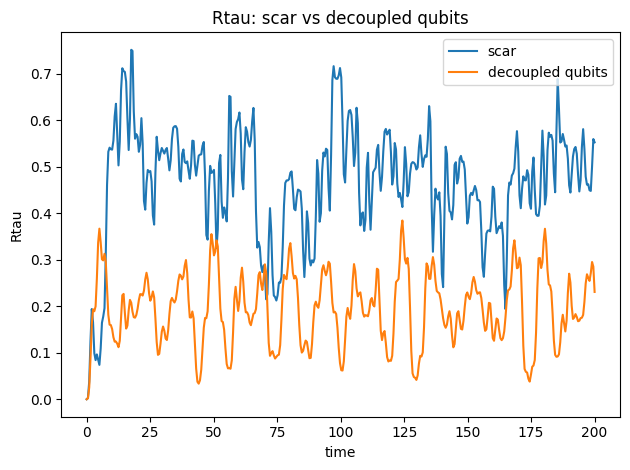

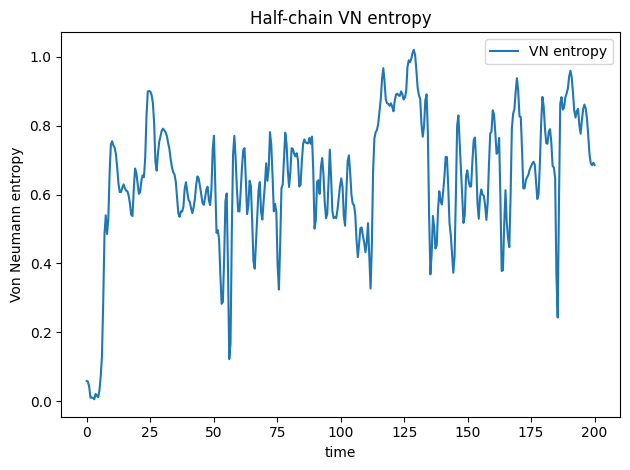

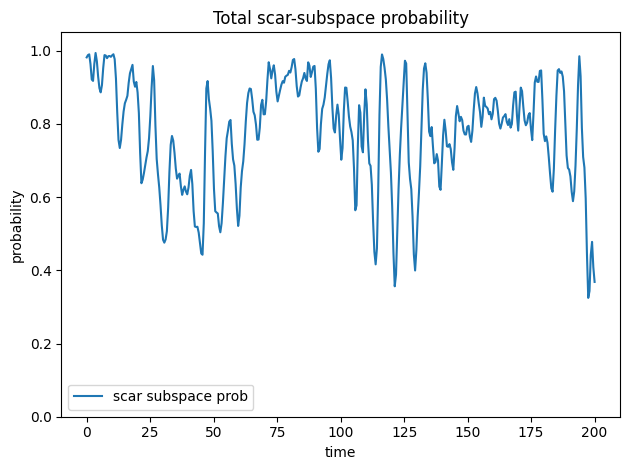

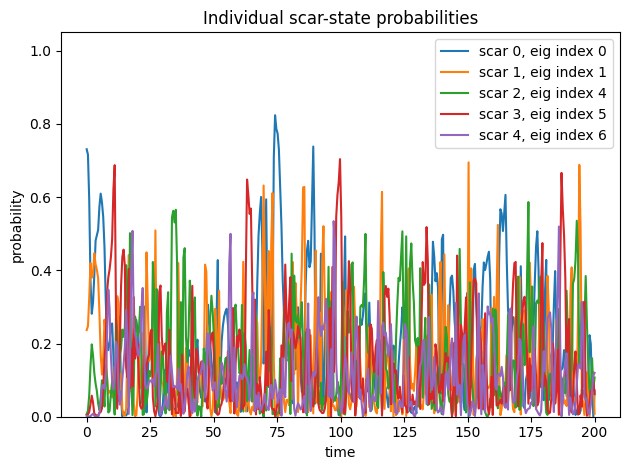

In [3]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_result_npz(result_dir):
    result_dir = Path(result_dir)

    if result_dir.is_file() and result_dir.suffix == ".npz":
        return result_dir

    matches = sorted(result_dir.glob("final/*_result.npz"))

    if not matches:
        matches = sorted(result_dir.glob("*_result.npz"))

    if not matches:
        raise FileNotFoundError(f"No *_result.npz found in {result_dir}")

    return matches[-1]


def main():
    if len(sys.argv) < 2:
        print("Usage:")
        print("  python plot_result.py /path/to/island_0")
        print("or")
        print("  python plot_result.py /path/to/final/result.npz")
        return

    npz_path = find_result_npz(r"C:/Users/idden/Mondragon_Stuff/GitHub_QM/Quantum_Batteries_Scars/ssh_py_files/island_0")
    print(f"Loading: {npz_path}")

    data = np.load(npz_path, allow_pickle=False)

    tlist = data["tlist"]

    print()
    print("Basic result:")
    print(f"N = {int(data['N'])}")
    print(f"x = {float(data['x'])}")
    print(f"y = {float(data['y'])}")
    print(f"z = {float(data['z'])}")
    print(f"ds = {float(data['ds'])}")
    print(f"dd = {float(data['dd'])}")
    print(f"final_score = {float(data['final_score'])}")
    print(f"max scar Rtau mean = {float(data['max_Rtau_scar_mean'])}")
    print(f"max qubit Rtau mean = {float(data['max_Rtau_qubit_mean'])}")

    if "scar_probs_all" in data.files:
        print(f"scar_probs_all shape = {data['scar_probs_all'].shape}")

    # ----------------------------
    # Plot Rtau scar vs qubits
    # ----------------------------
    plt.figure()
    plt.plot(tlist, data["Rtau_scar_mean"], label="scar")
    plt.fill_between(
        tlist,
        data["Rtau_scar_mean"] - data["Rtau_scar_std"],
        data["Rtau_scar_mean"] + data["Rtau_scar_std"],
        alpha=0.25,
    )

    plt.plot(tlist, data["Rtau_qubit_mean"], label="decoupled qubits")
    plt.fill_between(
        tlist,
        data["Rtau_qubit_mean"] - data["Rtau_qubit_std"],
        data["Rtau_qubit_mean"] + data["Rtau_qubit_std"],
        alpha=0.25,
    )

    plt.xlabel("time")
    plt.ylabel("Rtau")
    plt.title("Rtau: scar vs decoupled qubits")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot VN entropy
    # ----------------------------
    if "vn_entropy_mean" in data.files:
        plt.figure()
        plt.plot(tlist, data["vn_entropy_mean"], label="VN entropy")
        plt.fill_between(
            tlist,
            data["vn_entropy_mean"] - data["vn_entropy_std"],
            data["vn_entropy_mean"] + data["vn_entropy_std"],
            alpha=0.25,
        )
        plt.xlabel("time")
        plt.ylabel("Von Neumann entropy")
        plt.title("Half-chain VN entropy")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ----------------------------
    # Plot total scar-subspace probability
    # ----------------------------
    if "scar_subspace_prob_mean" in data.files:
        plt.figure()
        plt.plot(tlist, data["scar_subspace_prob_mean"], label="scar subspace prob")
        plt.fill_between(
            tlist,
            data["scar_subspace_prob_mean"] - data["scar_subspace_prob_std"],
            data["scar_subspace_prob_mean"] + data["scar_subspace_prob_std"],
            alpha=0.25,
        )
        plt.xlabel("time")
        plt.ylabel("probability")
        plt.ylim(0, 1.05)
        plt.title("Total scar-subspace probability")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ----------------------------
    # Plot individual scar probabilities
    # ----------------------------
    if "scar_probs_mean" in data.files:
        scar_probs_mean = data["scar_probs_mean"]
        scar_indices = data["scar_indices"]

        plt.figure()

        for i in range(scar_probs_mean.shape[0]):
            if i < len(scar_indices):
                label = f"scar {i}, eig index {scar_indices[i]}"
            else:
                label = f"scar {i}"

            plt.plot(tlist, scar_probs_mean[i], label=label)

        plt.xlabel("time")
        plt.ylabel("probability")
        plt.ylim(0, 1.05)
        plt.title("Individual scar-state probabilities")
        plt.legend()
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()